# Inverse Neural Gas on synthetic blobs

Train `InverseNeuralGas` on a simple 2D blob dataset and visualize the learned graph inline.

I remind that the only difference w.r.t. `NeuralGas` is in the scoring algorithm. I believe the inverse counterpart is more stable in real world scenarios and has less hyperparameters to tune.

Link to the original Neural Gas algorithm paper: https://www.ks.uiuc.edu/Publications/Papers/PDF/MART91B/MART91B.pdf

In [ ]:
#%pip install matplotlib

%matplotlib inline

from __future__ import annotations

import matplotlib.pyplot as plt
import torch
from ngas import InverseNeuralGas

In [67]:
def make_blobs(n_samples: int, seed: int, device: torch.device) -> torch.Tensor:
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)

    centers = torch.tensor(
        [[-2.0, -1.5], [0.5, 2.0], [2.5, -0.5]],
        dtype=torch.float32,
    )
    chunks = []
    per_center = n_samples // centers.size(0)
    for c in centers:
        points = c + 0.45 * torch.randn(per_center, 2, generator=g)
        chunks.append(points)

    rem = n_samples - per_center * centers.size(0)
    if rem > 0:
        points = centers[0] + 0.45 * torch.randn(rem, 2, generator=g)
        chunks.append(points)

    data = torch.cat(chunks, dim=0)
    perm = torch.randperm(data.size(0), generator=g)
    data = data[perm]
    return data.to(device=device)


def edge_count(adj: torch.Tensor) -> int:
    return int((adj >= 0).sum().item() // 2)


def plot_graph(data: torch.Tensor, model: InverseNeuralGas) -> None:
    pred = model.predict(data).cpu()
    x = data.cpu()
    w = model.weights.cpu()
    adj = model.adj.cpu()

    plt.figure(figsize=(8, 6))
    plt.scatter(x[:, 0], x[:, 1], c=pred, s=18, alpha=0.55, cmap="tab10")
    plt.scatter(w[:, 0], w[:, 1], c="black", s=80, marker="x", linewidths=2)

    idx = torch.triu_indices(adj.size(0), adj.size(1), offset=1)
    for i, j in zip(idx[0], idx[1]):
        if int(adj[i, j].item()) >= 0:
            p = w[i]
            q = w[j]
            plt.plot([p[0], q[0]], [p[1], q[1]], color="black", linewidth=0.8, alpha=0.4)

    plt.title("Inverse Neural Gas on Synthetic Blobs")
    plt.tight_layout()
    plt.show()

neurons=20
edges=23
quantization_error=0.314395


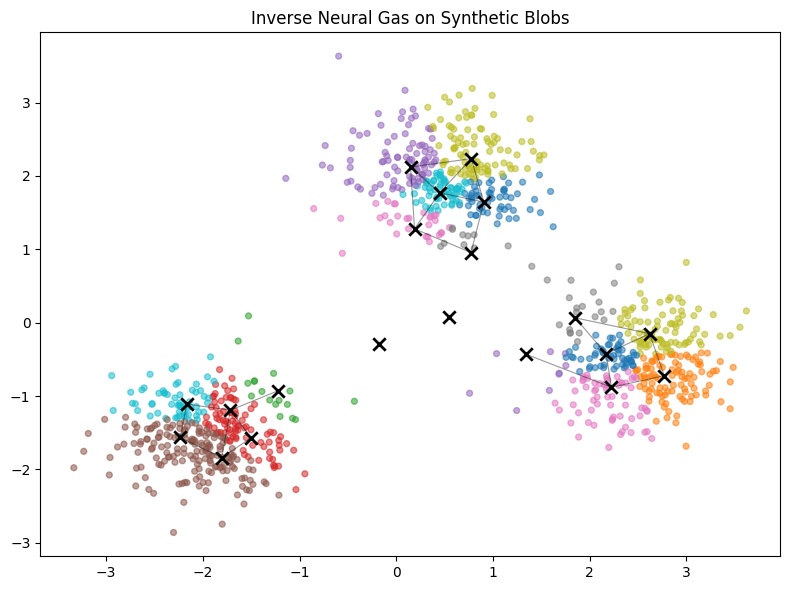

In [68]:
N_SAMPLES = 1000
N_NEURONS = 20
EPOCHS = 10
LR = 0.05
MAX_EDGE_AGE = 50
DISTANCE = "l2"
SEED = 7
DEVICE = torch.device("cpu")

#####################################

torch.manual_seed(SEED)
data = make_blobs(n_samples=N_SAMPLES, seed=SEED, device=DEVICE)
model = InverseNeuralGas(
    n_neurons=N_NEURONS,
    lr=LR,
    max_edge_age=MAX_EDGE_AGE,
    distance=DISTANCE,
    device=DEVICE,
)

model.fit(data, epochs=EPOCHS, shuffle=True)
qerr = model.quantization_error(data)

print(f"neurons={model.n_neurons}")
print(f"edges={edge_count(model.adj)}")
print(f"quantization_error={qerr:.6f}")

plot_graph(data, model)

You can delete nodes which are not part of a cluster, such that you end up with an approximated manifold.